# MaStar Preprocessing

This notebook gets the MaStar stellar spectral library (SDSS DR17) ready for our ML models. It handles the full pipeline: downloading the raw data from SDSS, filtering to good quality stars, normalizing the spectra, and saving everything to Drive.

Teammates should be able to load the output files directly without running any of this themselves.

Output files:
- `mastar_labeled_meta.csv`: labels and metadata for ~3,291 labeled stars (supervised)
- `mastar_labeled_spectra.npy`: continuum-normalized flux arrays for labeled stars
- `mastar_full_meta.csv`: metadata for ~15,200 good stars (unsupervised)
- `mastar_full_spectra.npy`: continuum-normalized flux arrays for all good stars
- `mastar_wave.npy`: shared wavelength grid (3622-10354 Angstroms, 4563 bins)

In [ ]:
!pip install astropy -q

In [ ]:
from astropy.io import fits
from matplotlib.collections import LineCollection
from scipy.ndimage import median_filter
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import gc
import gzip
import shutil

## Download

Downloads the MaStar good spectra file (~5GB) from SDSS to Drive. Only needs to run once. If it already exists, this cell does nothing.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/SIADS 696/data"
os.makedirs(DRIVE_DIR, exist_ok=True)

GOODSPEC_PATH = os.path.join(DRIVE_DIR, "mastar-goodspec-v3_1_1-v1_7_7.fits.gz")
CATALOG_URL   = "https://data.sdss.org/sas/dr17/manga/spectro/mastar/v3_1_1/v1_7_7/mastarall-v3_1_1-v1_7_7.fits"

if not os.path.exists(GOODSPEC_PATH):
    print("Downloading (~5GB, this takes a while)...")
    !wget -q --show-progress -O "{GOODSPEC_PATH}" \
        "https://data.sdss.org/sas/dr17/manga/spectro/mastar/v3_1_1/v1_7_7/mastar-goodspec-v3_1_1-v1_7_7.fits.gz"
    print("Done!")
else:
    print(f"Found at {GOODSPEC_PATH} ({os.path.getsize(GOODSPEC_PATH)/1e9:.2f} GB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found at /content/drive/MyDrive/SIADS 696/data/mastar-goodspec-v3_1_1-v1_7_7.fits.gz (5.76 GB)


## Decompress

We need to decompress the file before we can memory-map it. Astropy's `memmap=True` silently ignores the flag on gzipped files and just loads everything into RAM, which crashes Colab on a 5GB file. Decompressing to Drive first (~10GB uncompressed) lets us read individual rows on demand later.

In [ ]:
GOODSPEC_UNZIPPED = GOODSPEC_PATH.replace('.fits.gz', '.fits')

if not os.path.exists(GOODSPEC_UNZIPPED):
    print("Decompressing to Drive, takes a few minutes...")
    with gzip.open(GOODSPEC_PATH, 'rb') as f_in:
        with open(GOODSPEC_UNZIPPED, 'wb') as f_out:
            # Write in 64MB chunks so we don't spike RAM
            shutil.copyfileobj(f_in, f_out, length=1024 * 1024 * 64)
    print(f"Done ({os.path.getsize(GOODSPEC_UNZIPPED)/1e9:.1f} GB)")
else:
    print(f"Already decompressed ({GOODSPEC_UNZIPPED})")

Already decompressed (/content/drive/MyDrive/SIADS 696/data/mastar-goodspec-v3_1_1-v1_7_7.fits)


## Load and Filter the Catalog

The summary catalog is a small FITS file we can pull directly from SDSS. We build two working sets from it:

- **Labeled set**: stars with valid Teff, log g, and Fe/H entries. Used for supervised regression.
- **Full set**: all good stars regardless of labels. Used for unsupervised clustering.

We only keep visits where `MJDQUAL == 0`, meaning the spectrum passed all quality checks.

In [ ]:
def fits_to_df(hdu_data):
    # FITS tables store multi-dimensional columns and use big-endian byte order,
    # neither of which pandas handles natively. This flattens 2D columns into
    # separate named columns and converts everything to native byte order.
    cols = {}
    for col in hdu_data.columns.names:
        val = hdu_data[col]
        if val.ndim == 2:
            for i in range(val.shape[1]):
                cols[f"{col}_{i}"] = val[:, i].astype(val.dtype.newbyteorder('='))
        else:
            cols[col] = val.astype(val.dtype.newbyteorder('='))
    return pd.DataFrame(cols)

def teff_to_spectral_type(teff):
    # Standard Morgan-Keenan temperature boundaries
    if teff >= 30000: return 'O'
    elif teff >= 10000: return 'B'
    elif teff >= 7500:  return 'A'
    elif teff >= 6000:  return 'F'
    elif teff >= 5200:  return 'G'
    elif teff >= 3700:  return 'K'
    else:               return 'M'

print("Loading catalog...")
with fits.open(CATALOG_URL) as hdul:
    stars_df  = fits_to_df(hdul[1].data)  # GOODSTARS table
    visits_df = fits_to_df(hdul[2].data)  # GOODVISITS table

# MANGAID strings have trailing whitespace in the raw data
stars_df['MANGAID']  = stars_df['MANGAID'].str.strip()
visits_df['MANGAID'] = visits_df['MANGAID'].str.strip()

# Only keep visits that passed all quality checks
clean_visits = visits_df[visits_df['MJDQUAL'] == 0][['MANGAID', 'PLATE', 'IFUDESIGN', 'MJD', 'S2N']].copy()

# Labeled set: stars with all three target parameters present
# Sentinel values are 0 for TEFF and -999 for the others
labeled = stars_df[
    (stars_df['INPUT_TEFF'] > 0) &
    (stars_df['INPUT_LOGG'] > -999) &
    (stars_df['INPUT_FE_H'] > -999)
].copy()
labeled['SPECTRAL_TYPE'] = labeled['INPUT_TEFF'].apply(teff_to_spectral_type)

valid_clean = labeled[['MANGAID', 'SPECTRAL_TYPE', 'INPUT_TEFF', 'INPUT_LOGG', 'INPUT_FE_H']].merge(
    clean_visits, on='MANGAID', how='inner'
)

# Full set: all good stars with at least one clean visit, no label requirement
all_clean_visits = stars_df[['MANGAID']].merge(
    clean_visits, on='MANGAID', how='inner'
)

print(f"Total good stars:          {len(stars_df):,}")
print(f"Labeled stars:             {len(labeled):,}")
print(f"Labeled with clean visits: {valid_clean['MANGAID'].nunique():,}")
print(f"All stars with clean visits: {all_clean_visits['MANGAID'].nunique():,}")
print(f"\nSpectral type counts (labeled):")
print(valid_clean.drop_duplicates('MANGAID')['SPECTRAL_TYPE'].value_counts().to_string())

Loading catalog...
Total good stars:          24,290
Labeled stars:             4,258
Labeled with clean visits: 3,291
All stars with clean visits: 15,200

Spectral type counts (labeled):
SPECTRAL_TYPE
K    1936
G     634
F     470
A     179
M      72


## Continuum Normalization

Raw flux values are affected by a star's distance, dust along the line of sight, and instrument throughput on the night of observation. Two physically identical stars can have totally different raw flux scales depending on when and where they were observed. If we train on raw flux, the models pick up on brightness instead of spectral shape.

We normalize each spectrum by dividing by a smoothed version of itself. The smoother is a median filter with a 101-bin window (about 220 Angstroms), which is wide enough to span most absorption features without flattening them out. What's left after division is the spectral shape: the depths of absorption lines and the overall spectral slope, which are what actually encode Teff, log g, and Fe/H.

In [ ]:
def continuum_normalize(flux, window=101):
    flux = flux.astype(np.float32)

    # Clip negatives before filtering (bad pixels can go strongly negative)
    flux = np.clip(flux, 0, None)

    continuum = median_filter(flux, size=window)

    # If the continuum estimate is basically zero somewhere, don't divide by it
    min_continuum = 0.01 * np.median(flux[flux > 0]) if np.any(flux > 0) else 1.0
    continuum = np.where(continuum > min_continuum, continuum, 1.0)

    return flux / continuum

## Build and Save Flux Arrays

Reads spectra from the unzipped FITS file in batches of 500, normalizes each one, and writes directly to Drive-backed `.npy` files. We use numpy's `open_memmap` to pre-allocate the output array on disk, so we never hold the full dataset in RAM at once. Each batch gets flushed to Drive before moving on.

In [ ]:
BATCH_SIZE = 500

LABELED_META_PATH    = os.path.join(DRIVE_DIR, "mastar_labeled_meta.csv")
LABELED_SPECTRA_PATH = os.path.join(DRIVE_DIR, "mastar_labeled_spectra.npy")
FULL_META_PATH       = os.path.join(DRIVE_DIR, "mastar_full_meta.csv")
FULL_SPECTRA_PATH    = os.path.join(DRIVE_DIR, "mastar_full_spectra.npy")
WAVE_PATH            = os.path.join(DRIVE_DIR, "mastar_wave.npy")

def build_flux_npy(indices, out_path, label):
    n = len(indices)
    n_wave = len(wave)

    # Pre-allocate the output array on Drive so we never hold it all in RAM
    out_arr = np.lib.format.open_memmap(out_path, mode='w+', dtype=np.float32, shape=(n, n_wave))

    print(f"Building {label} ({n:,} spectra)...")
    with fits.open(GOODSPEC_UNZIPPED, memmap=True) as hdul:
        flux_data = hdul[1].data['FLUX']
        for start in tqdm(range(0, n, BATCH_SIZE), desc=label, unit="batch"):
            end = min(start + BATCH_SIZE, n)
            for j, idx in enumerate(indices[start:end]):
                out_arr[start + j] = continuum_normalize(flux_data[idx])
            out_arr.flush()
            gc.collect()

    del out_arr
    gc.collect()
    print(f"Saved to {out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")

# Build a row index from the goodspec file so we can look up stars by MANGAID
print("Reading goodspec index...")
with fits.open(GOODSPEC_UNZIPPED, memmap=True) as hdul:
    spec_data    = hdul[1].data
    wave         = spec_data['WAVE'][0].astype(np.float32)
    spec_mangaid = np.array([m.strip() for m in spec_data['MANGAID']])

visit_index = pd.DataFrame({'MANGAID': spec_mangaid, 'spec_idx': np.arange(len(spec_mangaid))})

# Bring in S/N from the catalog and pick the highest quality visit per star
visit_index = visit_index.merge(
    clean_visits[['MANGAID', 'S2N']].copy(), on='MANGAID', how='left'
)
best_visits = (visit_index
    .sort_values('S2N', ascending=False)
    .drop_duplicates('MANGAID')
)

# One row per star, with the file index we need to fetch its spectrum
labeled_merged = valid_clean.drop_duplicates('MANGAID').merge(
    best_visits[['MANGAID', 'spec_idx']], on='MANGAID', how='inner'
).reset_index(drop=True)

full_merged = all_clean_visits.drop_duplicates('MANGAID').merge(
    best_visits[['MANGAID', 'spec_idx']], on='MANGAID', how='inner'
).reset_index(drop=True)

labeled_meta = labeled_merged.drop(columns=['spec_idx', 'S2N'])
full_meta    = full_merged.drop(columns=['spec_idx', 'S2N'])

build_flux_npy(labeled_merged['spec_idx'].values, LABELED_SPECTRA_PATH, "labeled")
build_flux_npy(full_merged['spec_idx'].values,    FULL_SPECTRA_PATH,    "full")

np.save(WAVE_PATH, wave)
print("Done!")

Reading goodspec index...
Building labeled (3,291 spectra)...


labeled:   0%|          | 0/7 [00:00<?, ?batch/s]

Saved to /content/drive/MyDrive/SIADS 696/data/mastar_labeled_spectra.npy (60.1 MB)
Building full (15,200 spectra)...


full:   0%|          | 0/31 [00:00<?, ?batch/s]

Saved to /content/drive/MyDrive/SIADS 696/data/mastar_full_spectra.npy (277.4 MB)
Done!


## Save Metadata

The flux arrays are already on Drive from the step above. This just saves the metadata CSVs and prints a file size summary.

In [ ]:
labeled_meta.to_csv(LABELED_META_PATH, index=False)
full_meta.to_csv(FULL_META_PATH, index=False)

print("Files on Drive:")
for p in [LABELED_META_PATH, LABELED_SPECTRA_PATH, FULL_META_PATH, FULL_SPECTRA_PATH, WAVE_PATH]:
    print(f"  {os.path.basename(p)}: {os.path.getsize(p)/1e6:.1f} MB")

Files on Drive:
  mastar_labeled_meta.csv: 0.2 MB
  mastar_labeled_spectra.npy: 60.1 MB
  mastar_full_meta.csv: 0.5 MB
  mastar_full_spectra.npy: 277.4 MB
  mastar_wave.npy: 0.0 MB


## EDA: Parameter Space

Quick look at the labeled set before we hand it off. The Kiel diagram (Teff vs log g) is the standard visualization for stellar populations. Main sequence dwarfs cluster at high log g, giants sit lower. The histograms confirm what we noted in the proposal: the dataset skews heavily toward K-type stars, with hot stars being rare.

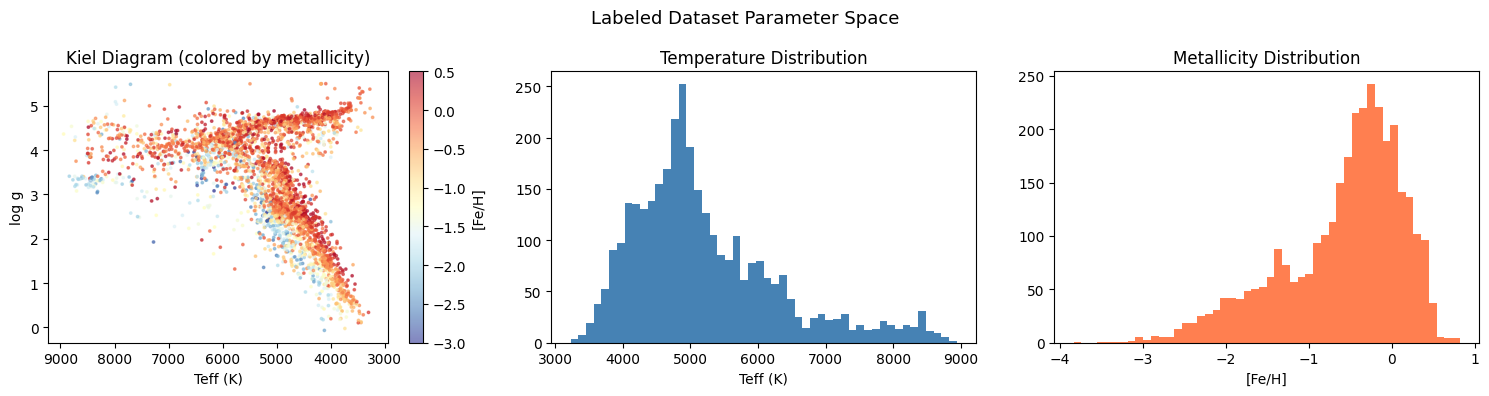

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc = axes[0].scatter(
    labeled_meta['INPUT_TEFF'],
    labeled_meta['INPUT_LOGG'],
    c=labeled_meta['INPUT_FE_H'],
    cmap='RdYlBu_r', s=3, alpha=0.6, vmin=-3, vmax=0.5
)
plt.colorbar(sc, ax=axes[0], label='[Fe/H]')
axes[0].set_xlabel('Teff (K)')
axes[0].set_ylabel('log g')
axes[0].set_title('Kiel Diagram (colored by metallicity)')
axes[0].invert_xaxis()

axes[1].hist(labeled_meta['INPUT_TEFF'], bins=50, color='steelblue')
axes[1].set_xlabel('Teff (K)')
axes[1].set_title('Temperature Distribution')

axes[2].hist(labeled_meta['INPUT_FE_H'], bins=50, color='coral')
axes[2].set_xlabel('[Fe/H]')
axes[2].set_title('Metallicity Distribution')

plt.suptitle('Labeled Dataset Parameter Space', fontsize=13)
plt.tight_layout()
plt.show()

## Load Arrays for Visualization

Loading with `mmap_mode='r'` means the array is referenced but not fully read into RAM. Only the rows we actually slice get loaded. Teammates should do the same.

In [ ]:
labeled_flux = np.load(LABELED_SPECTRA_PATH, mmap_mode='r')
wave         = np.load(WAVE_PATH)

print(f"labeled_flux: {labeled_flux.shape}")
print(f"wave:         {wave.shape}, {wave[0]:.0f}-{wave[-1]:.0f} Angstroms")

labeled_flux: (3291, 4563)
wave:         (4563,), 3622-10354 Angstroms


## EDA: Spectra by Spectral Type

One star per spectral class, shown raw (left) and normalized (right). We picked interesting edge cases rather than typical representatives: the hottest A star, the most metal-poor F star (probably a halo star), a G giant, the coolest K dwarf, and the hottest M star. The normalized versions are what goes into the models.

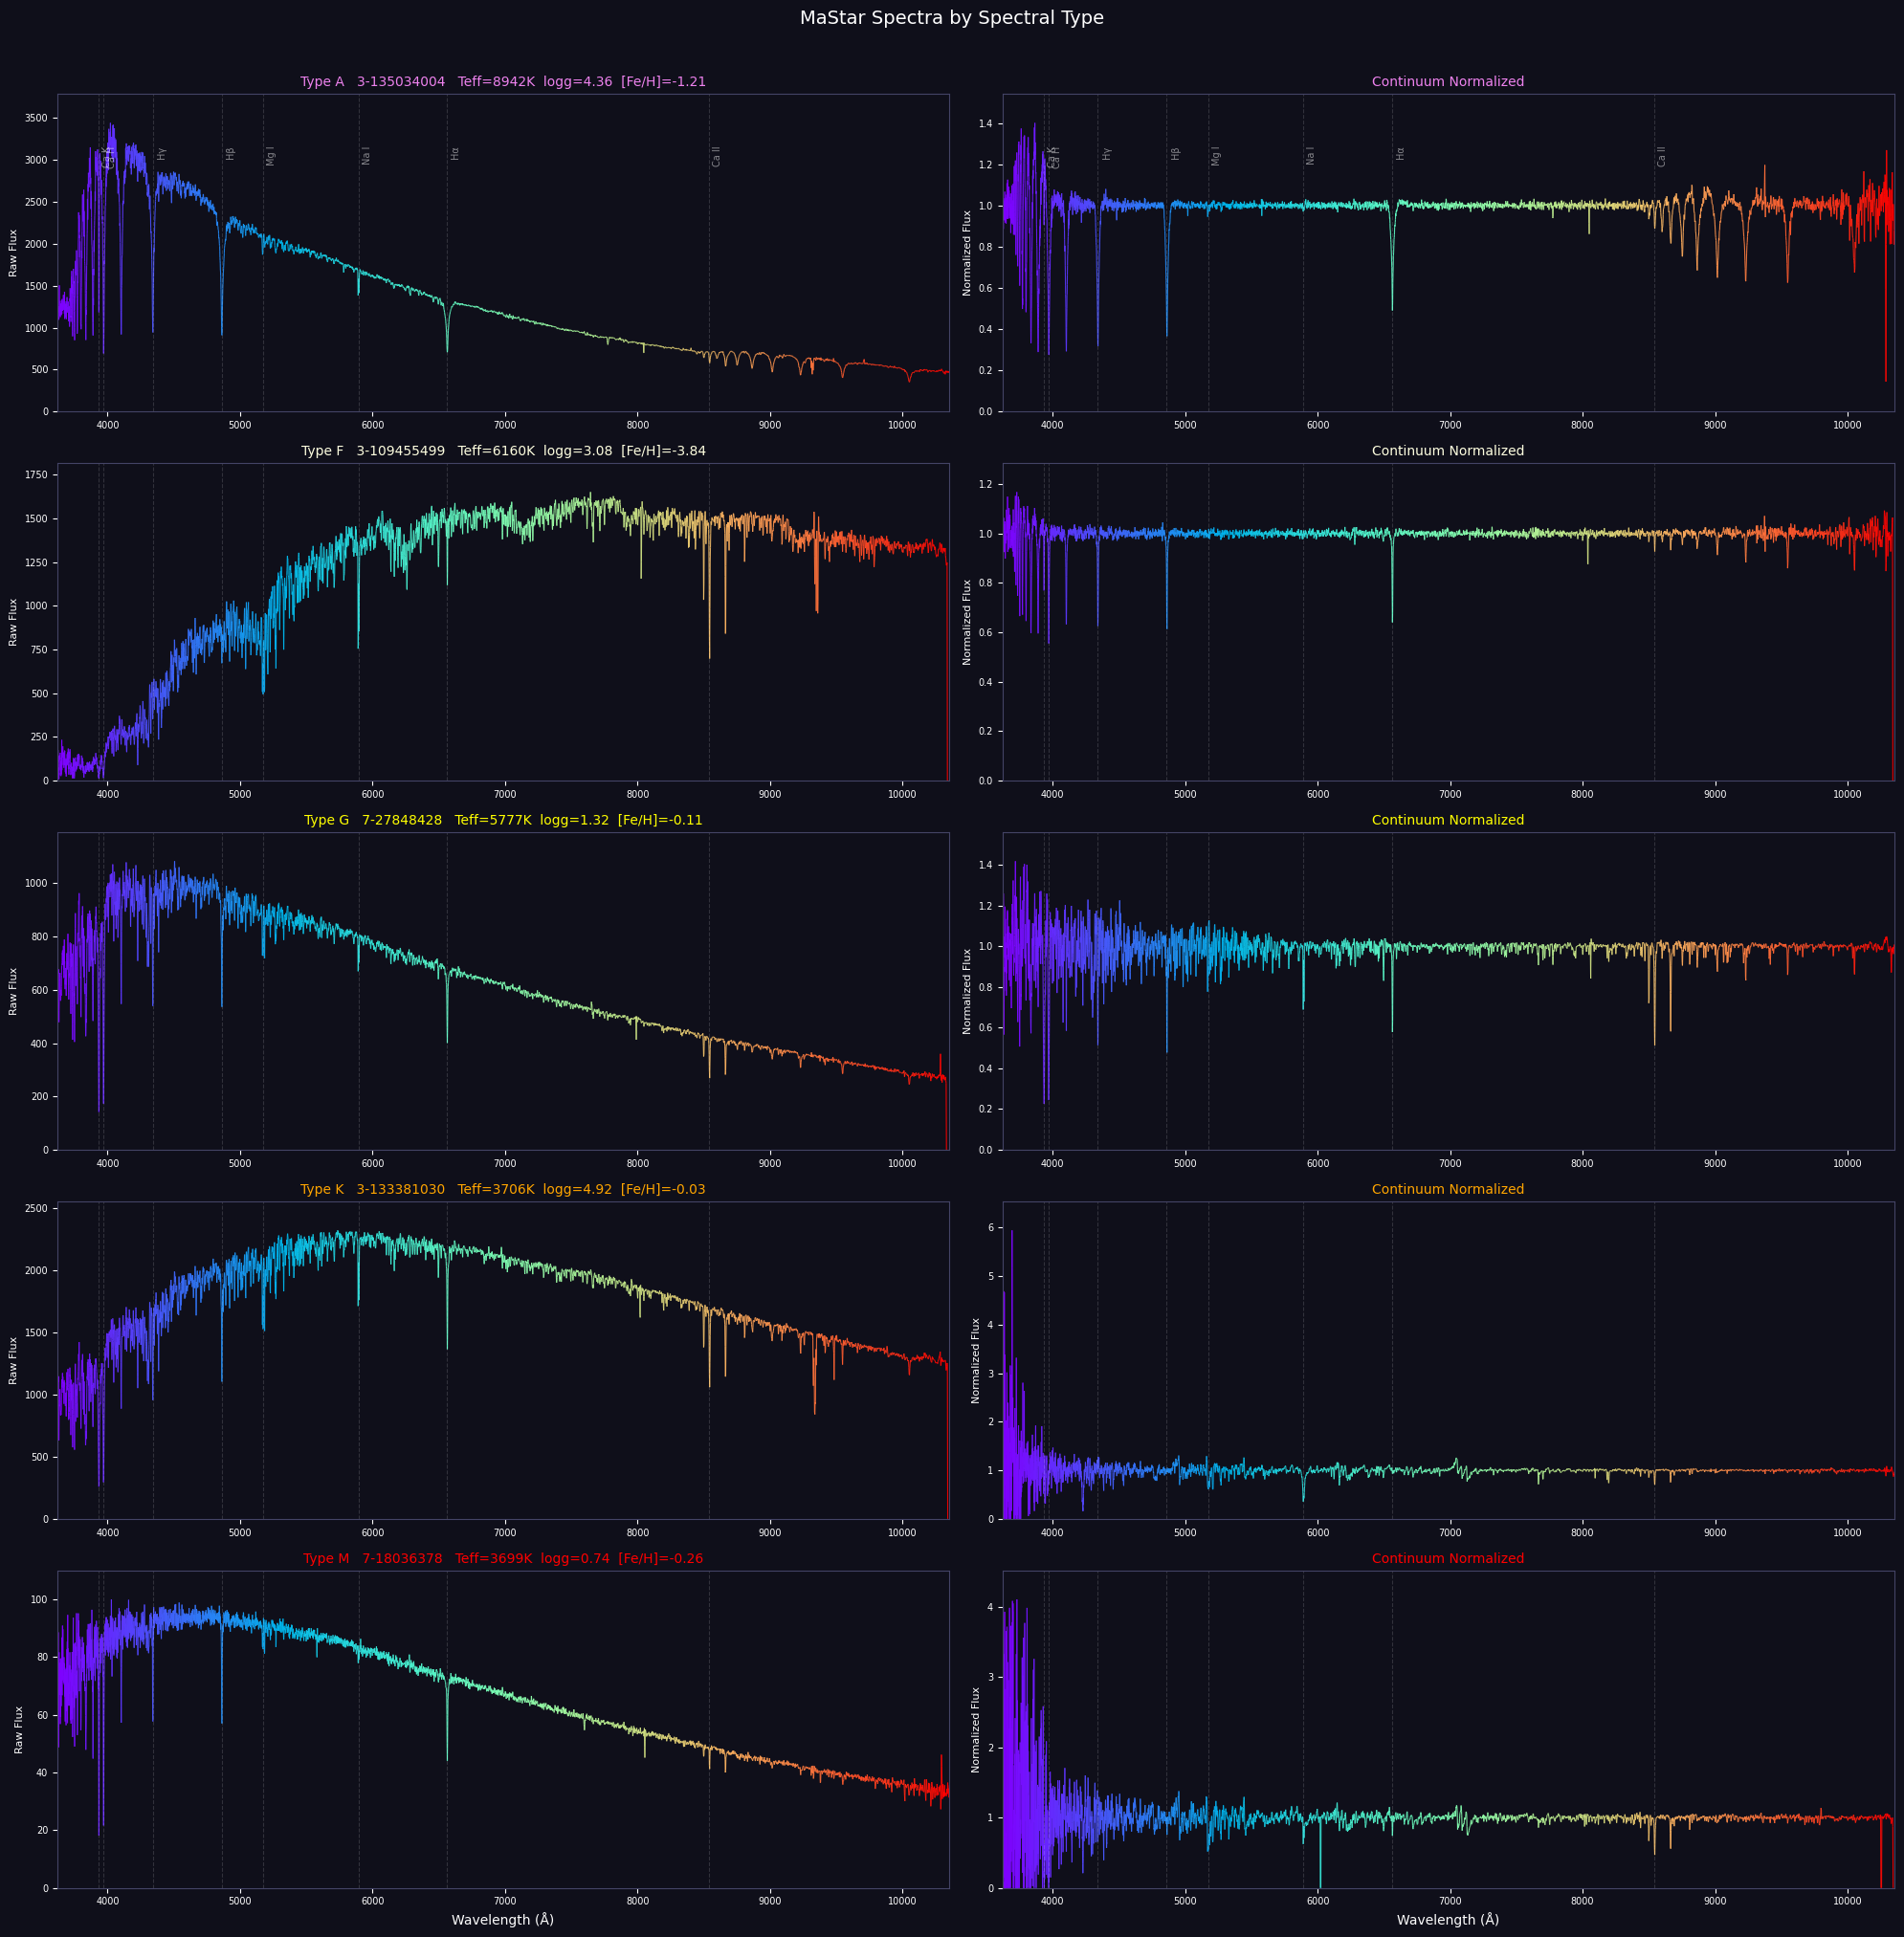

In [ ]:
ABSORPTION_LINES = {
    'Hα': 6563, 'Hβ': 4861, 'Hγ': 4341,
    'Ca K': 3933, 'Ca H': 3968,
    'Mg I': 5175, 'Na I': 5893, 'Ca II': 8542,
}
TYPE_COLORS = {'A': 'violet', 'F': 'lightyellow', 'G': 'yellow', 'K': 'orange', 'M': 'red'}

interesting_idx = {}
for stype, selector in [
    ('A', lambda d: d[d['SPECTRAL_TYPE']=='A']['INPUT_TEFF'].idxmax()),
    ('F', lambda d: d[d['SPECTRAL_TYPE']=='F']['INPUT_FE_H'].idxmin()),
    ('G', lambda d: d[(d['SPECTRAL_TYPE']=='G') & (d['INPUT_LOGG']<2.5)]['INPUT_LOGG'].idxmin()),
    ('K', lambda d: d[d['SPECTRAL_TYPE']=='K']['INPUT_TEFF'].idxmin()),
    ('M', lambda d: d[d['SPECTRAL_TYPE']=='M']['INPUT_TEFF'].idxmax()),
]:
    try:
        interesting_idx[stype] = selector(labeled_meta)
    except (ValueError, KeyError):
        pass

with fits.open(GOODSPEC_UNZIPPED, memmap=True) as hdul:
    flux_raw = {stype: hdul[1].data['FLUX'][pos].copy()
                for stype, pos in interesting_idx.items()}

n_types = len(interesting_idx)
fig, axes = plt.subplots(n_types, 2, figsize=(20, 4 * n_types))
fig.patch.set_facecolor('#0f0f1a')

for i, (stype, idx) in enumerate(interesting_idx.items()):
    star      = labeled_meta.iloc[idx]
    color     = TYPE_COLORS[stype]
    title_str = (f"Type {stype}   {star['MANGAID']}   "
                 f"Teff={star['INPUT_TEFF']:.0f}K  "
                 f"logg={star['INPUT_LOGG']:.2f}  "
                 f"[Fe/H]={star['INPUT_FE_H']:.2f}")

    for col, (flux, ylabel) in enumerate([
        (flux_raw[stype],        'Raw Flux'),
        (labeled_flux[idx].copy(), 'Normalized Flux'),
    ]):
        ax = axes[i, col]
        ax.set_facecolor('#0f0f1a')

        points   = np.array([wave, flux]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='rainbow',
                            norm=plt.Normalize(wave.min(), wave.max()),
                            linewidth=0.8, alpha=0.9)
        lc.set_array(wave)
        ax.add_collection(lc)

        for name, wl in ABSORPTION_LINES.items():
            if wave.min() < wl < wave.max():
                ax.axvline(wl, color='white', alpha=0.15, lw=0.8, linestyle='--')
                if i == 0:
                    ax.text(wl + 30, flux.max() * 0.92, name, color='white',
                            fontsize=7, alpha=0.5, rotation=90, va='top')

        ax.set_xlim(wave.min(), wave.max())
        ax.set_ylim(0, flux.max() * 1.1)
        ax.set_ylabel(ylabel, color='white', fontsize=8)
        ax.tick_params(colors='white', labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor('#444466')

        if col == 0:
            ax.set_title(title_str, color=color, fontsize=10, pad=6)
        else:
            ax.set_title('Continuum Normalized', color=color, fontsize=10, pad=6)

    axes[i, 0].set_xlabel('')
    axes[i, 1].set_xlabel('')

for col in range(2):
    axes[-1, col].set_xlabel('Wavelength (Å)', color='white')

plt.suptitle('MaStar Spectra by Spectral Type', color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## ML Readiness Check

Before passing the data to teammates, we run a quick sanity check. This catches shape mismatches, NaNs, Infs, and label values that look like sentinel placeholders that slipped through filtering.

In [ ]:
print("Running checks...\n")

labeled_flux_check = np.load(LABELED_SPECTRA_PATH, mmap_mode='r')
full_flux_check    = np.load(FULL_SPECTRA_PATH,    mmap_mode='r')
labeled_meta_check = pd.read_csv(LABELED_META_PATH)
full_meta_check    = pd.read_csv(FULL_META_PATH)
wave_check         = np.load(WAVE_PATH)

passed = True

def check(name, condition, detail=""):
    global passed
    if not condition:
        passed = False
    status = "PASS" if condition else "FAIL"
    suffix = f" ({detail})" if detail else ""
    print(f"  [{status}] {name}{suffix}")

# Shape sanity
check("Labeled flux rows match metadata",
      labeled_flux_check.shape[0] == len(labeled_meta_check),
      f"{labeled_flux_check.shape[0]} vs {len(labeled_meta_check)}")

check("Full flux rows match metadata",
      full_flux_check.shape[0] == len(full_meta_check),
      f"{full_flux_check.shape[0]} vs {len(full_meta_check)}")

check("Flux columns match wavelength grid",
      labeled_flux_check.shape[1] == len(wave_check),
      f"{labeled_flux_check.shape[1]} bins")

# Sample 500 rows for NaN/Inf checks (checking all 15k rows is slow over mmap)
rng = np.random.default_rng(42)
labeled_sample = labeled_flux_check[rng.choice(len(labeled_flux_check), 500, replace=False)]
full_sample    = full_flux_check[rng.choice(len(full_flux_check),    500, replace=False)]

check("No NaNs in labeled flux",  not np.isnan(labeled_sample).any())
check("No Infs in labeled flux",  not np.isinf(labeled_sample).any())
check("No NaNs in full flux",     not np.isnan(full_sample).any())
check("No Infs in full flux",     not np.isinf(full_sample).any())

# Normalized flux should sit broadly around 1.0
med = float(np.median(labeled_sample))
check("Labeled flux median near 1.0", 0.5 < med < 1.5, f"median={med:.3f}")

# Label completeness
for col in ['INPUT_TEFF', 'INPUT_LOGG', 'INPUT_FE_H']:
    n_null = labeled_meta_check[col].isnull().sum()
    check(f"No nulls in {col}", n_null == 0, f"{n_null} nulls")

# Label ranges: catch sentinel values that slipped through
teff = labeled_meta_check['INPUT_TEFF']
logg = labeled_meta_check['INPUT_LOGG']
feh  = labeled_meta_check['INPUT_FE_H']

check("Teff range looks right", teff.between(2500, 50000).all(),
      f"{teff.min():.0f} to {teff.max():.0f} K")
check("log g range looks right", logg.between(-1, 6).all(),
      f"{logg.min():.2f} to {logg.max():.2f}")
check("Fe/H range looks right", feh.between(-5, 1).all(),
      f"{feh.min():.2f} to {feh.max():.2f}")

# Wavelength grid
check("Wavelength range looks right",
      3600 < wave_check[0] < 3700 and 10300 < wave_check[-1] < 10500,
      f"{wave_check[0]:.0f} to {wave_check[-1]:.0f} Angstroms")

print(f"\n{'All good!' if passed else 'Some checks failed, review before handing off.'}")

Running checks...

  [PASS] Labeled flux rows match metadata (3291 vs 3291)
  [PASS] Full flux rows match metadata (15200 vs 15200)
  [PASS] Flux columns match wavelength grid (4563 bins)
  [PASS] No NaNs in labeled flux
  [PASS] No Infs in labeled flux
  [PASS] No NaNs in full flux
  [PASS] No Infs in full flux
  [PASS] Labeled flux median near 1.0 (median=1.000)
  [PASS] No nulls in INPUT_TEFF (0 nulls)
  [PASS] No nulls in INPUT_LOGG (0 nulls)
  [PASS] No nulls in INPUT_FE_H (0 nulls)
  [PASS] Teff range looks right (3226 to 8942 K)
  [PASS] log g range looks right (-0.07 to 5.50)
  [PASS] Fe/H range looks right (-3.84 to 0.82)
  [PASS] Wavelength range looks right (3622 to 10354 Angstroms)

All good!


## For Teammates: Loading the Data

All files are in the shared Drive folder (`SIADS 696/data`). Mount Drive and load what you need:

```python
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
DRIVE_DIR = "/content/drive/MyDrive/SIADS 696/data"

# Labeled set (supervised learning)
labeled_meta = pd.read_csv(f"{DRIVE_DIR}/mastar_labeled_meta.csv")
labeled_flux = np.load(f"{DRIVE_DIR}/mastar_labeled_spectra.npy", mmap_mode='r')

# Full set (unsupervised learning)
full_meta = pd.read_csv(f"{DRIVE_DIR}/mastar_full_meta.csv")
full_flux = np.load(f"{DRIVE_DIR}/mastar_full_spectra.npy", mmap_mode='r')

# Shared wavelength grid
wave = np.load(f"{DRIVE_DIR}/mastar_wave.npy")
```

**What each file contains:**

`mastar_labeled_meta.csv` (3,291 rows): one row per labeled star. Columns: `MANGAID` (unique star ID), `SPECTRAL_TYPE` (derived from Teff), `INPUT_TEFF` (effective temperature in K), `INPUT_LOGG` (surface gravity), `INPUT_FE_H` (metallicity). These three INPUT columns are the regression targets for supervised learning.

`mastar_labeled_spectra.npy` (3,291 x 4,563): continuum-normalized flux arrays for the labeled stars. Row order matches `labeled_meta` exactly.

`mastar_full_meta.csv` (15,200 rows): same structure as the labeled metadata but for all good stars regardless of whether they have labels. Use this for unsupervised learning.

`mastar_full_spectra.npy` (15,200 x 4,563): continuum-normalized flux arrays for all good stars. Row order matches `full_meta` exactly.

`mastar_wave.npy` (4,563 values): the shared wavelength axis in Angstroms, ranging from roughly 3622 to 10354. Every row in every flux array corresponds to this same grid.

**A few things worth knowing:**

- `mmap_mode='r'` loads the array as a memory map, meaning rows are only pulled from disk when you actually slice them. For a dataset this size, always load this way.
- `labeled_flux[i]` gives the normalized spectrum for `labeled_meta.iloc[i]`. Row order is guaranteed to match between flux arrays and their corresponding metadata CSVs.
- Flux values are continuum normalized, so values broadly sit around 1.0. Raw flux is not saved.